
# Triadic Cell Notebook v12
## Slot-template anchoring, bank-native decoding, storage-geometry repair

v10 showed that decoding harder was not enough.
v11 was set up to test whether the bank's own geometry was the right decoding space.

This notebook pushes the next intervention directly:

1. **bank-native decoder**
   - decode against the actual stored slot templates

2. **reset-per-slot storage**
   - remove cross-pattern carryover

3. **slot-template anchoring**
   - during supervised writes, blend the write target toward the assigned prototype
   - this explicitly repairs slot geometry instead of only decoding around it

4. **margin metrics**
   - measure how decisively a recalled vector belongs to one slot instead of another

The question now is:

> if raw write discipline is already decent, can we improve recall by making the stored slot manifold cleaner?



## What is new in v12

The new experimental knob is `template_pull`.

When a pattern is written to a supervised slot, the stored value becomes:

\[
v_{write} = (1-\alpha)\,v_{latent} + \alpha\,v_{template}
\]

where:
- `v_latent` is what the cell would naturally write
- `v_template` is the slot's assigned prototype
- `\alpha` is the anchoring strength

This is not claimed as "the final ontology".
It is a direct intervention on storage geometry.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)

        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 2):
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(
                self.slots[i] + strength * masked[i] * value,
                0.0, 1.0
            )
        return masked.copy()

    def decay_only(self, steps: int = 1):
        self.slots *= (1.0 - self.leak) ** steps

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def copy(self):
        return copy.deepcopy(self)


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))


def nearest_index_and_margin(vec: np.ndarray, library: np.ndarray):
    sims = np.array([cosine_similarity(vec, p) for p in library], dtype=float)
    order = np.argsort(sims)[::-1]
    best = int(order[0])
    top1 = float(sims[order[0]])
    top2 = float(sims[order[1]]) if len(order) > 1 else 0.0
    return best, top1, top1 - top2


In [5]:

class TriadicCellV12:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        write_enabled: bool = True,
        target_slot: int | None = None,
        novelty_threshold: float = 0.10,
        template_pull: float = 0.0,
        templates: np.ndarray | None = None,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        base_write_strength = float(0.60 * support * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            write_value = np.clip((1.0 - template_pull) * latent + template_pull * templates[target_slot], 0.0, 1.0)

        if write_enabled:
            bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, recalled.copy(), addr.copy(), write_strength, novelty


class PlainTRBaselineV12:
    def __init__(self):
        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = cue / (np.linalg.norm(cue) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        write_enabled: bool = True,
        target_slot: int | None = None,
        novelty_threshold: float = 0.10,
        template_pull: float = 0.0,
        templates: np.ndarray | None = None,
    ):
        query = s.latent / (np.linalg.norm(s.latent) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))
        composite_target = 0.72 * drive_vec + 0.28 * recalled
        latent = self._clip(s.latent + 0.10 * coherence * (composite_target - s.latent) - 0.18 * s.latent)

        delta_vec = np.abs(latent - s.latent)
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.35 * projected - 0.35 * s.readout)

        base_write_strength = float(0.08 * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            write_value = np.clip((1.0 - template_pull) * latent + template_pull * templates[target_slot], 0.0, 1.0)

        if write_enabled:
            bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, recalled.copy(), addr.copy(), write_strength, novelty


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],  # -> slot 0
    [0.05, 1.00, 0.05, 0.05],  # -> slot 1
    [0.05, 0.05, 1.00, 0.05],  # -> slot 2
    [0.05, 0.05, 0.05, 1.00],  # -> slot 3
], dtype=float)


In [7]:

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    cue = np.clip(cue, 0.0, 1.0)
    return cue


def store_patterns(model, bank: KeyedMemoryBank, cycles_per_pattern: int = 18, reset_per_slot: bool = False, template_pull: float = 0.0):
    state = AddressedTriadicState()
    for slot_idx, p in enumerate(patterns):
        if reset_per_slot:
            state = AddressedTriadicState()
        for _ in range(cycles_per_pattern):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state, *_ = model.step(
                state,
                drive,
                bank,
                write_enabled=True,
                target_slot=slot_idx,
                novelty_threshold=0.10,
                template_pull=template_pull,
                templates=patterns,
            )
    return bank.slot_energy().copy(), bank.slots.copy()


def probe_patterns(model, bank: KeyedMemoryBank, proto_library: np.ndarray, bank_templates: np.ndarray, trials_per_pattern: int = 24) -> pd.DataFrame:
    rows = []
    for idx, p in enumerate(patterns):
        for _ in range(trials_per_pattern):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)

            pred_raw = int(np.argmax(addr))
            pred_proto, sim_proto, margin_proto = nearest_index_and_margin(recalled, proto_library)
            pred_bank, sim_bank, margin_bank = nearest_index_and_margin(recalled, bank_templates)

            rows.append({
                "target_slot": idx,
                "pred_raw": pred_raw,
                "pred_proto": pred_proto,
                "pred_bank": pred_bank,
                "sim_raw": cosine_similarity(recalled, p),
                "sim_proto": sim_proto,
                "sim_bank": sim_bank,
                "margin_proto": margin_proto,
                "margin_bank": margin_bank,
            })
    return pd.DataFrame(rows)


def run_condition(model_name: str, triadic: bool, reset_per_slot: bool, template_pull: float):
    model = TriadicCellV12(1.0, 1.0, 1.0) if triadic else PlainTRBaselineV12()
    bank = KeyedMemoryBank(width=4, leak=0.015)

    slot_energy, templates = store_patterns(
        model, bank, cycles_per_pattern=18, reset_per_slot=reset_per_slot, template_pull=template_pull
    )
    probe_df = probe_patterns(model, bank, patterns, templates, trials_per_pattern=24)

    summary = {
        "model": model_name,
        "storage_mode": "reset" if reset_per_slot else "sequential",
        "template_pull": template_pull,
        "raw_accuracy": float((probe_df["pred_raw"] == probe_df["target_slot"]).mean()),
        "proto_accuracy": float((probe_df["pred_proto"] == probe_df["target_slot"]).mean()),
        "bank_accuracy": float((probe_df["pred_bank"] == probe_df["target_slot"]).mean()),
        "raw_similarity": float(probe_df["sim_raw"].mean()),
        "proto_similarity": float(probe_df["sim_proto"].mean()),
        "bank_similarity": float(probe_df["sim_bank"].mean()),
        "mean_proto_margin": float(probe_df["margin_proto"].mean()),
        "mean_bank_margin": float(probe_df["margin_bank"].mean()),
        "slot_divergence": float(np.std(slot_energy)),
    }
    return summary, probe_df, slot_energy, templates

runs = []
details = {}

conditions = [
    ("BTR", True, False, 0.0),
    ("BTR", True, True, 0.0),
    ("BTR", True, True, 0.35),
    ("Plain TR baseline", False, True, 0.0),
]

for model_name, triadic, reset_per_slot, template_pull in conditions:
    summary, probe_df, slot_energy, templates = run_condition(
        model_name, triadic, reset_per_slot, template_pull
    )
    runs.append(summary)
    key = (model_name, "reset" if reset_per_slot else "sequential", template_pull)
    details[key] = {
        "probe": probe_df,
        "slot_energy": slot_energy,
        "templates": templates,
    }

summary_df = pd.DataFrame(runs)
summary_df


,model,storage_mode,template_pull,raw_accuracy,proto_accuracy,bank_accuracy,raw_similarity,proto_similarity,bank_similarity,mean_proto_margin,mean_bank_margin,slot_divergence
0,BTR,sequential,0.00,0.541667,0.541667,0.541667,0.619052,0.792086,0.993078,0.147247,0.226325,0.023231
1,BTR,reset,0.00,0.500000,0.489583,0.520833,0.635740,0.835926,0.990015,0.308370,0.209345,0.012521
2,BTR,reset,0.35,0.552083,0.552083,0.562500,0.656733,0.889144,0.988487,0.433509,0.320889,0.004419
3,Plain TR baseline,reset,0.00,0.489583,0.385417,0.510417,0.583969,0.765841,0.998938,0.160857,0.035831,0.000627



## Accuracy comparison


In [8]:

summary_df[["model", "storage_mode", "template_pull", "raw_accuracy", "proto_accuracy", "bank_accuracy"]]


,model,storage_mode,template_pull,raw_accuracy,proto_accuracy,bank_accuracy
0,BTR,sequential,0.00,0.541667,0.541667,0.541667
1,BTR,reset,0.00,0.500000,0.489583,0.520833
2,BTR,reset,0.35,0.552083,0.552083,0.562500
3,Plain TR baseline,reset,0.00,0.489583,0.385417,0.510417


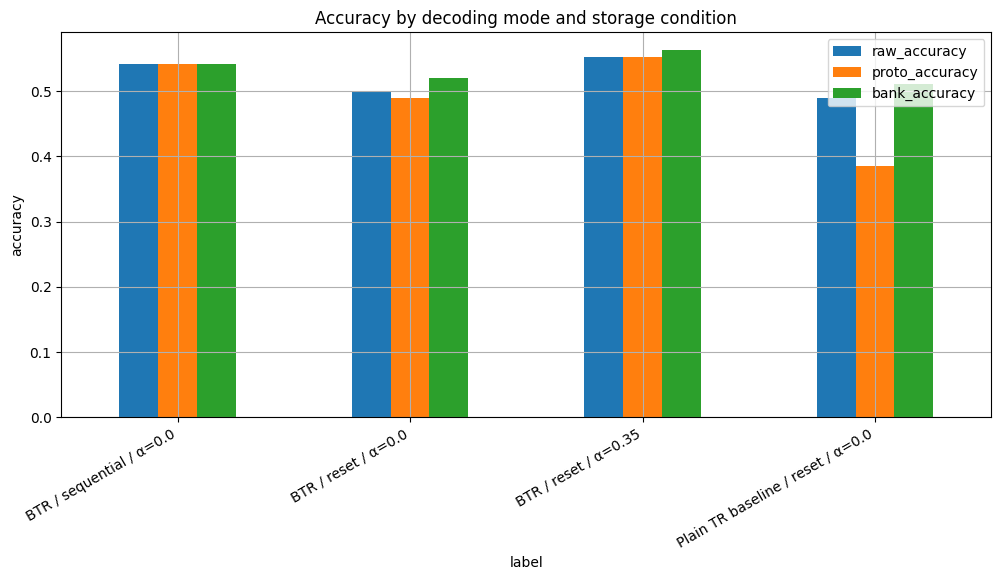

In [9]:

plot_df = summary_df.copy()
plot_df["label"] = plot_df["model"] + " / " + plot_df["storage_mode"] + " / α=" + plot_df["template_pull"].astype(str)
plot_df = plot_df.set_index("label")[["raw_accuracy", "proto_accuracy", "bank_accuracy"]]
plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Accuracy by decoding mode and storage condition")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.show()



## Similarity and margin comparison


In [10]:

summary_df[["model", "storage_mode", "template_pull", "raw_similarity", "proto_similarity", "bank_similarity", "mean_proto_margin", "mean_bank_margin", "slot_divergence"]]


,model,storage_mode,template_pull,raw_similarity,proto_similarity,bank_similarity,mean_proto_margin,mean_bank_margin,slot_divergence
0,BTR,sequential,0.00,0.619052,0.792086,0.993078,0.147247,0.226325,0.023231
1,BTR,reset,0.00,0.635740,0.835926,0.990015,0.308370,0.209345,0.012521
2,BTR,reset,0.35,0.656733,0.889144,0.988487,0.433509,0.320889,0.004419
3,Plain TR baseline,reset,0.00,0.583969,0.765841,0.998938,0.160857,0.035831,0.000627



## Slot energies


In [11]:

energy_df = pd.DataFrame({
    f"{model} / {mode} / α={alpha}": details[(model, mode, alpha)]["slot_energy"]
    for model, mode, alpha in details.keys()
}, index=[f"slot_{i}" for i in range(4)])
energy_df


,BTR / sequential / α=0.0,BTR / reset / α=0.0,BTR / reset / α=0.35,Plain TR baseline / reset / α=0.0
slot_0,0.019491,0.019036,0.004605,0.000540
slot_1,0.077044,0.008026,0.001934,0.000346
slot_2,0.072910,0.003350,0.001770,0.000271
slot_3,0.045065,0.035889,0.012638,0.001815


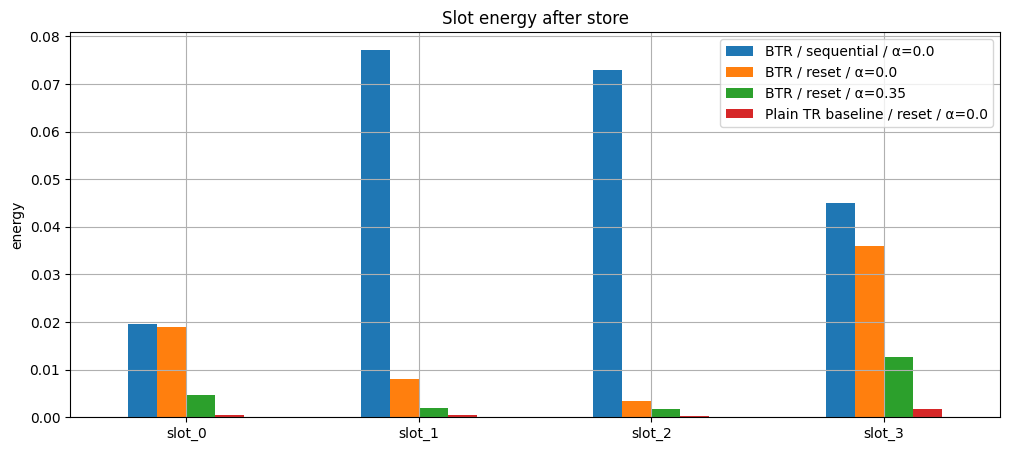

In [12]:

energy_df.plot(kind="bar", figsize=(12, 5))
plt.title("Slot energy after store")
plt.ylabel("energy")
plt.xticks(rotation=0)
plt.show()



## Bank-native templates


In [13]:

for key, item in details.items():
    model, mode, alpha = key
    print(f"{model} / {mode} / α={alpha}")
    display(pd.DataFrame(item["templates"], index=[f"slot_{i}" for i in range(4)], columns=[f"d{i}" for i in range(4)]))


BTR / sequential / α=0.0


,d0,d1,d2,d3
slot_0,0.036274,0.013998,0.020505,0.007186
slot_1,0.120206,0.153833,0.019719,0.014420
slot_2,0.029468,0.121727,0.127489,0.012956
slot_3,0.009296,0.018094,0.070941,0.081929


BTR / reset / α=0.0


,d0,d1,d2,d3
slot_0,0.035372,0.014229,0.020212,0.006330
slot_1,0.003793,0.016547,0.008763,0.002999
slot_2,0.001844,0.002980,0.007109,0.001468
slot_3,0.016625,0.026176,0.036041,0.064714


BTR / reset / α=0.35


,d0,d1,d2,d3
slot_0,0.009512,0.003093,0.004267,0.001548
slot_1,0.000855,0.004236,0.001945,0.000698
slot_2,0.000812,0.001317,0.004307,0.000646
slot_3,0.005255,0.008224,0.011046,0.026027


Plain TR baseline / reset / α=0.0


,d0,d1,d2,d3
slot_0,0.000605,0.000547,0.000772,0.000238
slot_1,0.000207,0.000536,0.000487,0.000153
slot_2,0.000167,0.000289,0.000500,0.000128
slot_3,0.001079,0.001838,0.002623,0.001718



## Read the result

What matters now:

- does **bank-native decoding** beat raw and prototype decoding?
- does **reset-per-slot** help?
- does **template anchoring** help?
- does the baseline remain weak under the same tests?

If bank decoding and reset/anchoring help,
then the remaining bottleneck was storage contamination + manifold mismatch,
not the core triadic write discipline itself.
